In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('superstore.csv', encoding='latin-1')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales * 100).round(2)
total_orders = df.shape[0]
total_customers = df['Customer ID'].nunique()

print("=" * 40)
print(f"💰 Total Sales:       ${total_sales:,.2f}")
print(f"📈 Total Profit:      ${total_profit:,.2f}")
print(f"📊 Profit Margin:     {profit_margin}%")
print(f"🛒 Total Orders:      {total_orders:,}")
print(f"👥 Total Customers:   {total_customers:,}")
print("=" * 40)

💰 Total Sales:       $2,297,200.86
📈 Total Profit:      $286,397.02
📊 Profit Margin:     12.47%
🛒 Total Orders:      9,994
👥 Total Customers:   793


In [7]:
# Fix - recreate all date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Year'] = df['Order Date'].dt.to_period('M').astype(str)
df['Profit Margin'] = (df['Profit'] / df['Sales'] * 100).round(2)

print("✅ Columns Fixed!")
print(df.columns.tolist())

✅ Columns Fixed!
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Month_Year', 'Profit Margin']


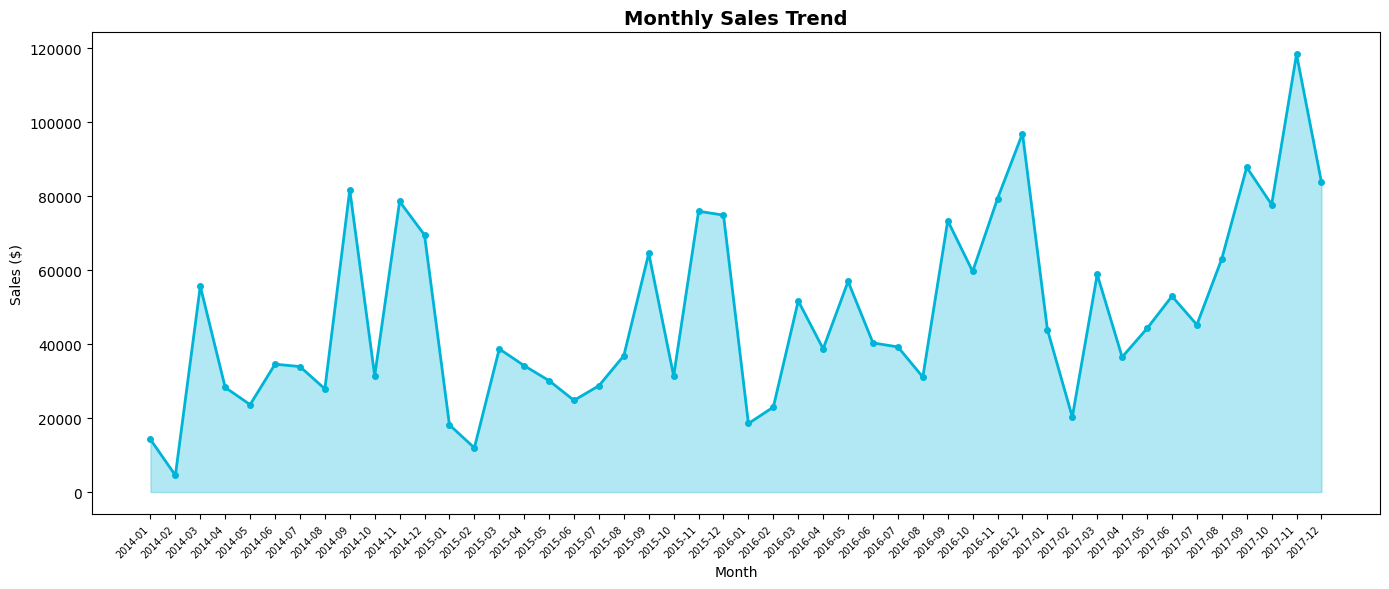

✅ Saved!


In [8]:
monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Month_Year'], monthly_sales['Sales'],
         color='#00B4D8', linewidth=2, marker='o', markersize=4)
plt.fill_between(range(len(monthly_sales)), monthly_sales['Sales'],
                 alpha=0.3, color='#00B4D8')
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(range(len(monthly_sales)), monthly_sales['Month_Year'],
           rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig('sales_trend.png', dpi=150)
plt.show()
print("✅ Saved!")

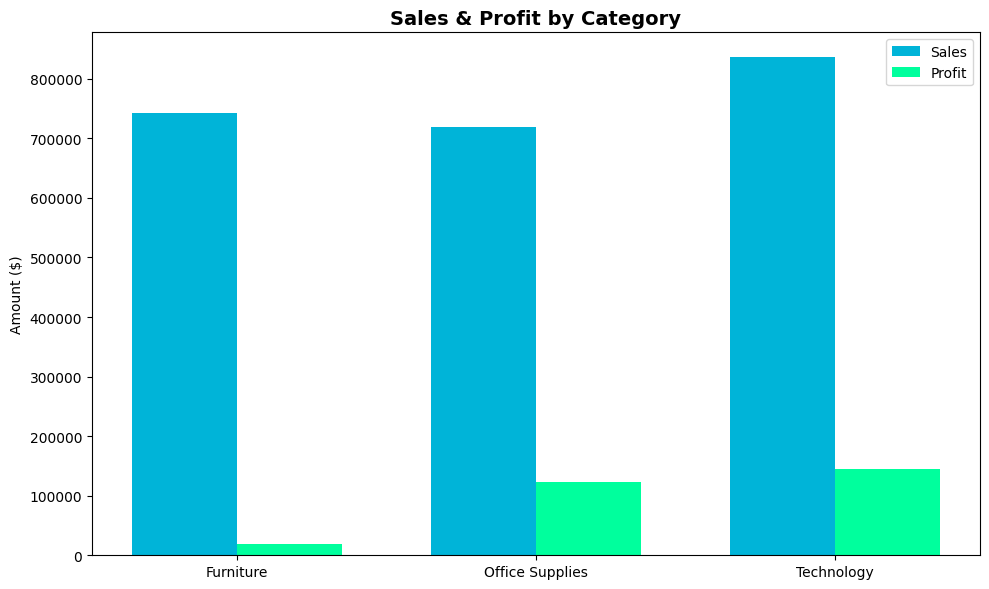

✅ Saved!


In [9]:
category_data = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(category_data))
width = 0.35
ax.bar([i - width/2 for i in x], category_data['Total_Sales'],
       width, label='Sales', color='#00B4D8')
ax.bar([i + width/2 for i in x], category_data['Total_Profit'],
       width, label='Profit', color='#00FF9D')
ax.set_xticks(x)
ax.set_xticklabels(category_data['Category'])
ax.set_title('Sales & Profit by Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Amount ($)')
ax.legend()
plt.tight_layout()
plt.savefig('category_performance.png', dpi=150)
plt.show()
print("✅ Saved!")

/tmp/ipython-input-966/3283276408.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='Region', y='Sales', palette='Blues_d')


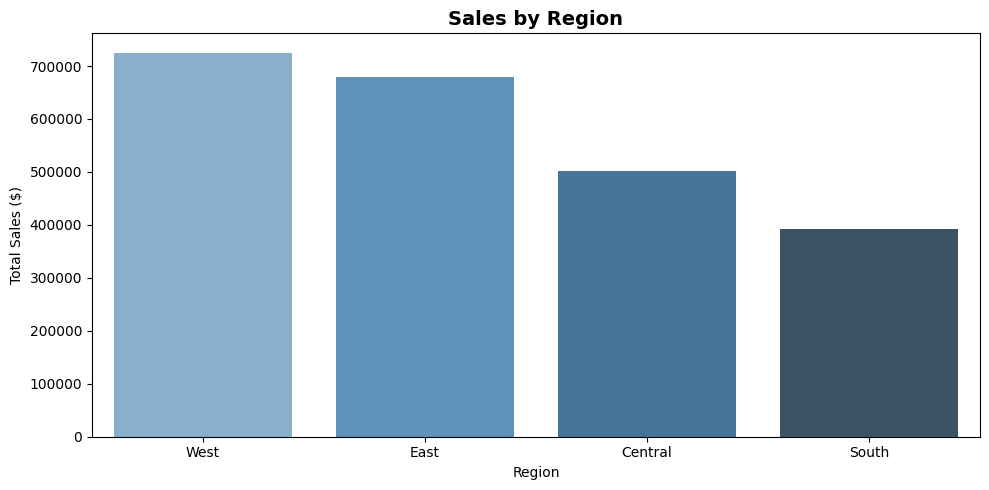

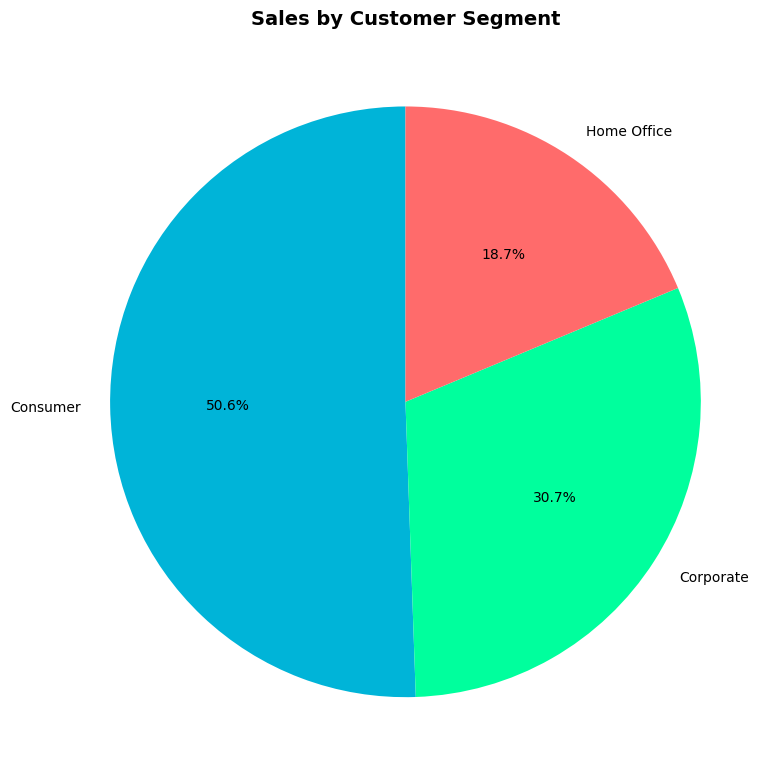

✅ Saved!


In [10]:
# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
region_sales = region_sales.sort_values('Sales', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=region_sales, x='Region', y='Sales', palette='Blues_d')
plt.title('Sales by Region', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('sales_by_region.png', dpi=150)
plt.show()

# Sales by Segment
segment_sales = df.groupby('Segment')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 8))
plt.pie(segment_sales['Sales'], labels=segment_sales['Segment'],
        autopct='%1.1f%%', colors=['#00B4D8', '#00FF9D', '#FF6B6B'],
        startangle=90)
plt.title('Sales by Customer Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sales_by_segment.png', dpi=150)
plt.show()
print("✅ Saved!")

/tmp/ipython-input-966/1621429466.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_products, x='Sales', y='Product Name', palette='Blues_d')


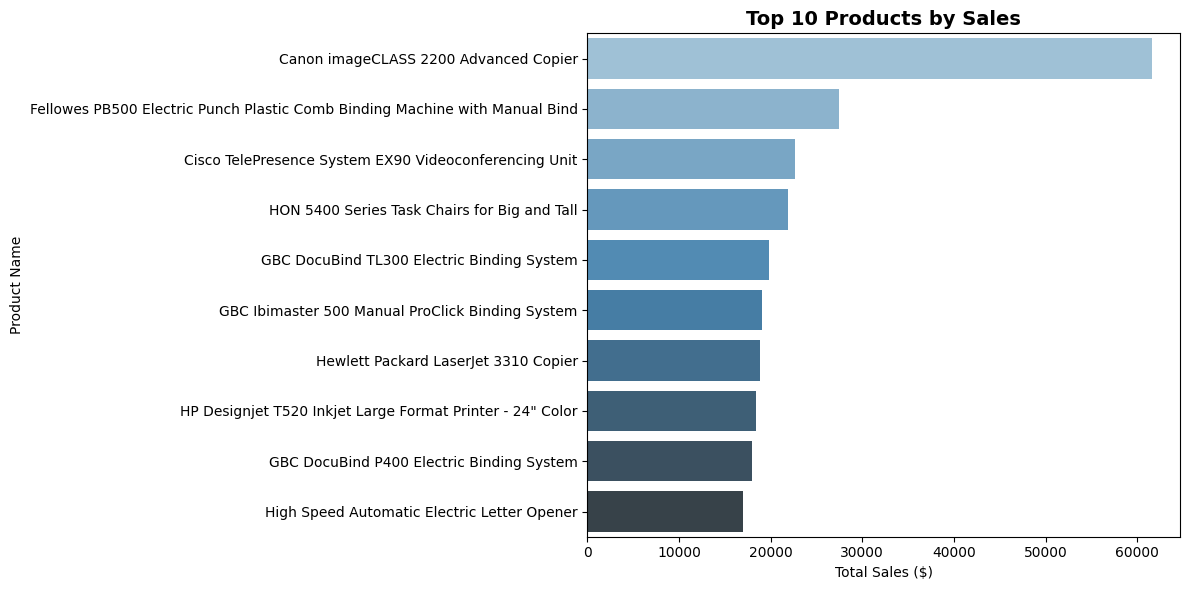

/tmp/ipython-input-966/1621429466.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loss_products, x='Profit', y='Product Name', palette='Reds_d')


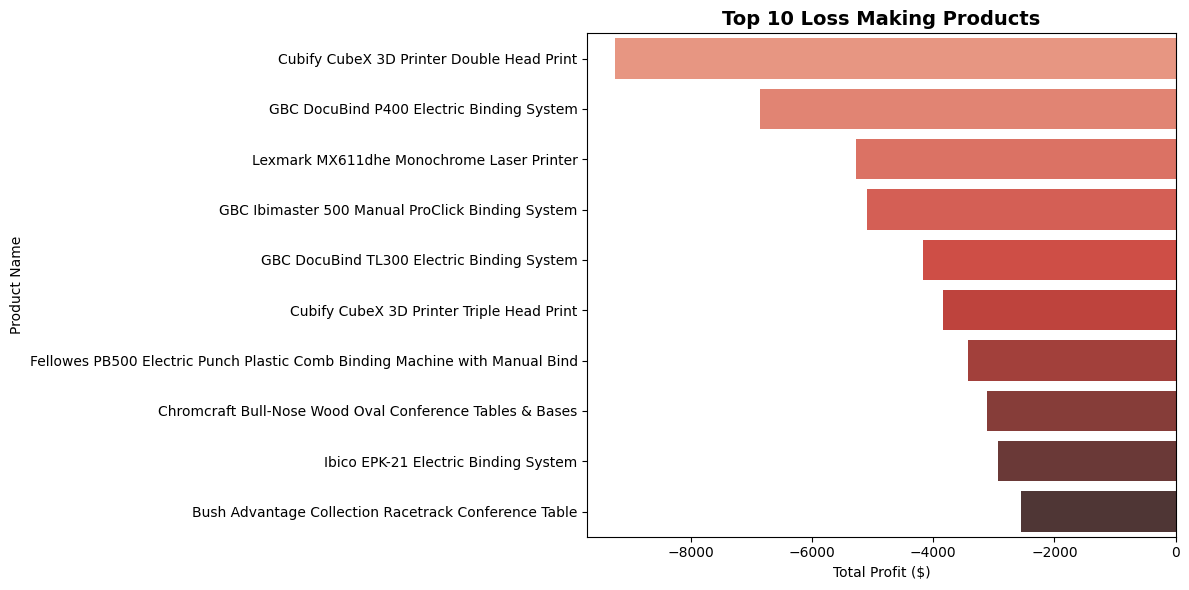

✅ Saved!


In [11]:
# Top 10 products by sales
top10_products = df.groupby('Product Name')['Sales'].sum().reset_index()
top10_products = top10_products.nlargest(10, 'Sales')

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_products, x='Sales', y='Product Name', palette='Blues_d')
plt.title('Top 10 Products by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('top10_products.png', dpi=150)
plt.show()

# Products with negative profit
loss_products = df[df['Profit'] < 0].groupby('Product Name')['Profit'].sum().reset_index()
loss_products = loss_products.nsmallest(10, 'Profit')

plt.figure(figsize=(12, 6))
sns.barplot(data=loss_products, x='Profit', y='Product Name', palette='Reds_d')
plt.title('Top 10 Loss Making Products', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('loss_products.png', dpi=150)
plt.show()
print("✅ Saved!")

In [12]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('superstore', conn, index=False, if_exists='replace')

# Query 1 — Revenue by Region
q1 = pd.read_sql_query("""
    SELECT Region,
           ROUND(SUM(Sales), 2) as Total_Sales,
           ROUND(SUM(Profit), 2) as Total_Profit,
           ROUND(SUM(Profit)/SUM(Sales)*100, 2) as Profit_Margin_Pct
    FROM superstore
    GROUP BY Region
    ORDER BY Total_Sales DESC
""", conn)
print("Revenue by Region:")
print(q1)

# Query 2 — Top 5 Sub-Categories
q2 = pd.read_sql_query("""
    SELECT [Sub-Category],
           ROUND(SUM(Sales), 2) as Total_Sales,
           ROUND(SUM(Profit), 2) as Total_Profit
    FROM superstore
    GROUP BY [Sub-Category]
    ORDER BY Total_Sales DESC
    LIMIT 5
""", conn)
print("\nTop 5 Sub-Categories:")
print(q2)

# Query 3 — Yearly Performance
q3 = pd.read_sql_query("""
    SELECT Year,
           ROUND(SUM(Sales), 2) as Total_Sales,
           ROUND(SUM(Profit), 2) as Total_Profit,
           COUNT(DISTINCT [Customer ID]) as Unique_Customers
    FROM superstore
    GROUP BY Year
    ORDER BY Year
""", conn)
print("\nYearly Performance:")
print(q3)

# Query 4 — Customer Segment Performance
q4 = pd.read_sql_query("""
    SELECT Segment,
           ROUND(SUM(Sales), 2) as Total_Sales,
           ROUND(AVG(Sales), 2) as Avg_Order_Value,
           COUNT(DISTINCT [Customer ID]) as Total_Customers
    FROM superstore
    GROUP BY Segment
    ORDER BY Total_Sales DESC
""", conn)
print("\nCustomer Segment Performance:")
print(q4)

Revenue by Region:
    Region  Total_Sales  Total_Profit  Profit_Margin_Pct
0     West    725457.82     108418.45              14.94
1     East    678781.24      91522.78              13.48
2  Central    501239.89      39706.36               7.92
3    South    391721.91      46749.43              11.93

Top 5 Sub-Categories:
  Sub-Category  Total_Sales  Total_Profit
0       Phones    330007.05      44515.73
1       Chairs    328449.10      26590.17
2      Storage    223843.61      21278.83
3       Tables    206965.53     -17725.48
4      Binders    203412.73      30221.76

Yearly Performance:
   Year  Total_Sales  Total_Profit  Unique_Customers
0  2014    484247.50      49543.97               595
1  2015    470532.51      61618.60               573
2  2016    609205.60      81795.17               638
3  2017    733215.26      93439.27               693

Customer Segment Performance:
       Segment  Total_Sales  Avg_Order_Value  Total_Customers
0     Consumer   1161401.34           223.

In [13]:
df.to_csv('superstore_cleaned.csv', index=False)
q1.to_csv('revenue_by_region.csv', index=False)
q3.to_csv('yearly_performance.csv', index=False)

print("✅ All Files Saved:")
print("   - superstore_cleaned.csv")
print("   - revenue_by_region.csv")
print("   - yearly_performance.csv")
print("   - sales_trend.png")
print("   - category_performance.png")
print("   - sales_by_region.png")
print("   - sales_by_segment.png")
print("   - top10_products.png")
print("   - loss_products.png")
print("\n✅ Python Analysis Complete!")

✅ All Files Saved:
   - superstore_cleaned.csv
   - revenue_by_region.csv
   - yearly_performance.csv
   - sales_trend.png
   - category_performance.png
   - sales_by_region.png
   - sales_by_segment.png
   - top10_products.png
   - loss_products.png

✅ Python Analysis Complete!
